In [29]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [39]:
# 1. Load the data
msft = r'\Users\Troy\Downloads\tchin-heston-volatility-option-pricer\src\data\msft_data.csv' 
df = pd.read_csv(msft)

# 2. Inspect data (separate statements with newlines instead of semicolons for readability)
print(df.head(10))
print(df.describe().T)

# 3. Separate features and target
target = 'Open'
X = df.drop(columns=target)
y = df[target]

# 4. Split data (20% test, 80% train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Check shapes
print(X_test.shape, y_test.shape)


                        Date        Open        High         Low       Close  \
0  2020-01-02 00:00:00-05:00  150.090263  151.933540  149.664893  151.829559   
1  2020-01-03 00:00:00-05:00  149.655410  151.196193  149.409630  149.938980   
2  2020-01-06 00:00:00-05:00  148.483276  150.392729  147.944465  150.326553   
3  2020-01-07 00:00:00-05:00  150.600711  150.931547  148.710167  148.955933   
4  2020-01-08 00:00:00-05:00  150.232003  151.999671  149.305641  151.328522   
5  2020-01-09 00:00:00-05:00  152.982768  153.341976  152.217100  153.219086   
6  2020-01-10 00:00:00-05:00  153.909144  154.287247  152.358885  152.510132   
7  2020-01-13 00:00:00-05:00  152.907147  154.372321  152.434511  154.343964   
8  2020-01-14 00:00:00-05:00  154.447980  154.646494  152.869378  153.256943   
9  2020-01-15 00:00:00-05:00  153.720101  154.967867  153.672849  154.249451   

     Volume  Dividends  Stock Splits  
0  22622100        0.0           0.0  
1  21116200        0.0           0.0  
2 

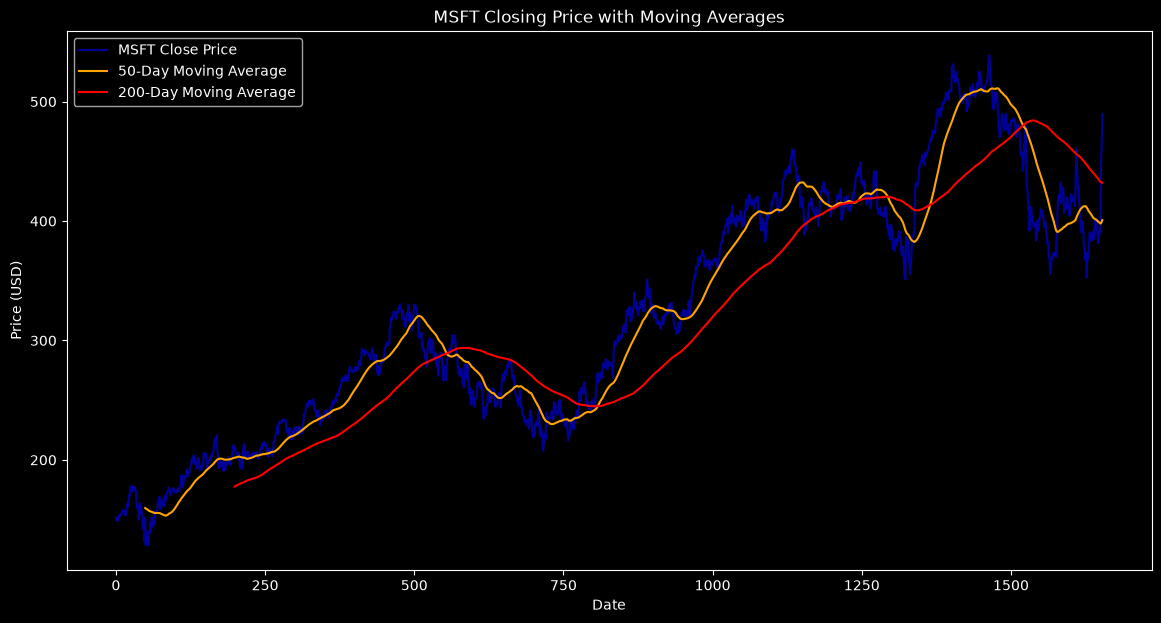

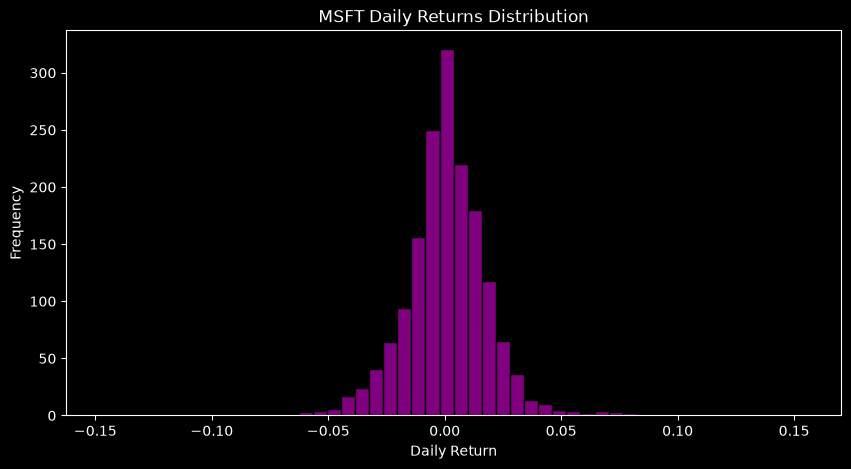

In [40]:
df.columns = df.columns.get_level_values(0)

# 2. Visualize Closing Price and Moving Averages
df['MA_50'] = df['Close'].rolling(window=50).mean() 
df['MA_200'] = df['Close'].rolling(window=200).mean() 


plt.style.use('dark_background')
plt.figure(figsize=(14, 7)) 
plt.plot(df['Close'], label='MSFT Close Price', color='blue', alpha=0.6) 
plt.plot(df['MA_50'], label='50-Day Moving Average', color='orange') 
plt.plot(df['MA_200'], label='200-Day Moving Average', color='red') 
plt.title('MSFT Closing Price with Moving Averages') 
plt.xlabel('Date') 
plt.ylabel('Price (USD)') 
plt.legend() 
plt.show() 

# 3. Analyze Daily Returns 
df['Daily_Return'] = df['Close'].pct_change() 

plt.figure(figsize=(10, 5)) 
plt.hist(df['Daily_Return'].dropna(), bins=50, color='purple', edgecolor='black') 
plt.title('MSFT Daily Returns Distribution') 
plt.xlabel('Daily Return') 
plt.ylabel('Frequency') 
plt.show()
